In [2]:
!pip install kaggle --quiet

In [3]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [40]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algord/fake-news")

print("Path to dataset files:", path)

100%|██████████| 1.68M/1.68M [00:00<00:00, 80.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/algord/fake-news/versions/1


In [12]:
import os

print(os.listdir(path))

['FakeNewsNet.csv']


In [ ]:
import os

print(os.listdir(path))

['FakeNewsNet.csv']


In [14]:
file_path = os.path.join(path, "FakeNewsNet.csv")
df = pd.read_csv(file_path)

df.head()


,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [15]:
df.shape

(23196, 5)

Im going to use title and source domain to train my model

In [16]:
#check for null values
df.isnull().sum()

,0
title,0
news_url,330
source_domain,330
tweet_num,0
real,0


In [17]:
#replace missing values with empty string
df=df.fillna(' ')

I want to check the relationship between number of tweets and the nature of the tweet (real or fake)

In [20]:
# group data by 'real' column and compute mean tweet count
print("\nAverage tweet count:")
print(df.groupby('real')['tweet_num'].mean())




Average tweet count:
real
0    132.693484
1     74.525027
Name: tweet_num, dtype: float64


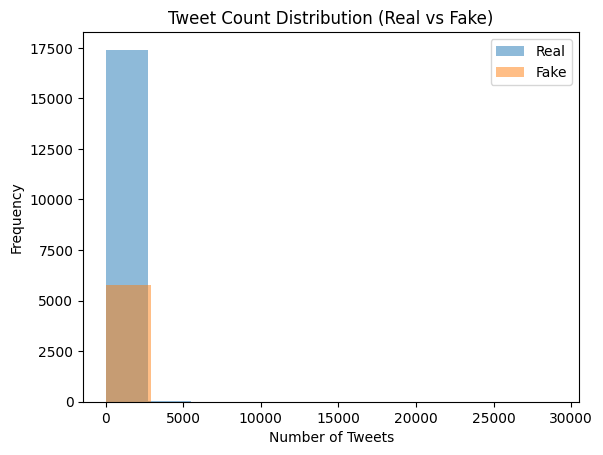

In [21]:
import matplotlib.pyplot as plt
real = df[df['real'] == 1]['tweet_num']
fake = df[df['real'] == 0]['tweet_num']

# plot histogram for comparison
plt.figure()
plt.hist(real, alpha=0.5, label='Real')   # real news distribution
plt.hist(fake, alpha=0.5, label='Fake')   # fake news distribution

plt.xlabel("Number of Tweets")
plt.ylabel("Frequency")
plt.title("Tweet Count Distribution (Real vs Fake)")
plt.legend()
plt.show()


/tmp/ipykernel_1716/746849269.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([real, fake], labels=['Real', 'Fake'])


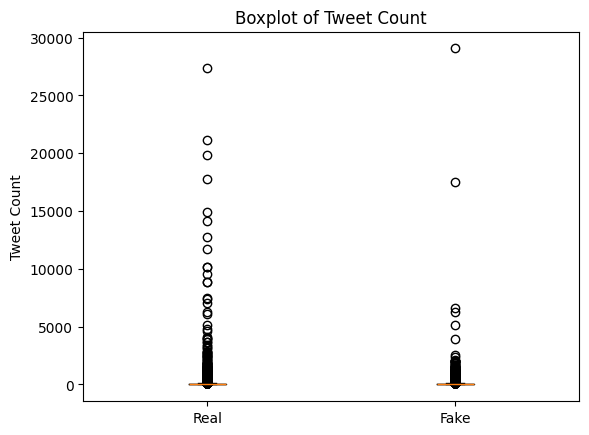

In [23]:
plt.figure()
plt.boxplot([real, fake], labels=['Real', 'Fake'])

plt.ylabel("Tweet Count")
plt.title("Boxplot of Tweet Count")
plt.show()

Running logistic regression model usinf features; title and source

In [27]:
# merging the title and source
df['content'] = df['title']+' '+ df['source_domain']

In [28]:
print(df['content'])

0        Kandi Burruss Explodes Over Rape Accusation on...
1        People's Choice Awards 2018: The best red carp...
2        Sophia Bush Sends Sweet Birthday Message to 'O...
3        Colombian singer Maluma sparks rumours of inap...
4        Gossip Girl 10 Years Later: How Upper East Sid...
                               ...                        
23191    Pippa Middleton wedding: In case you missed it...
23192    Zayn Malik & Gigi Hadid’s Shocking Split: Why ...
23193    Jessica Chastain Recalls the Moment Her Mother...
23194    Tristan Thompson Feels "Dumped" After Khloé Ka...
23195    Kelly Clarkson Performs a Medley of Kendrick L...
Name: content, Length: 23196, dtype: object


In [33]:
X=df['content']
y=df['real']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [34]:
vectorizer=TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vec=vectorizer.fit_transform(X_train)
X_test_vec=vectorizer.transform(X_test)

In [35]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [36]:
y_pred=model.predict(X_test_vec)

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8588362068965517
